# Polly — Copy-Trading the Top 100 Polymarket Performers

**Question:** If you mechanically copied the bets of Polymarket's best-performing
traders, would you make money — and which *way* of copying works best?

This notebook builds an end-to-end analytics pipeline on **public Polymarket data**:

1. **Find available stats for the top ~100 performers** (leaderboard PnL/volume).
2. **Define multiple copy-trading strategies** (different ways of mirroring bets).
3. **Split the trade timeline into train / validation / test** by date,
   fit each strategy's parameters on train/val, and **report ROI on a held-out
   test period** that the strategies never saw.

### Data sources (all public, unauthenticated)
| Source | Endpoint | What it gives |
|---|---|---|
| Leaderboard | `lb-api.polymarket.com/{profit,volume}` | top performers (caps at 50/window) |
| Activity | `data-api.polymarket.com/activity` | every BUY/SELL with price, size, time |
| Resolution | `clob.polymarket.com/markets/<id>` | which outcome won (settlement) |

Raw data was pulled by `src/collect_data.py` into `../data/`.

### The copy model (one formula)
A *copyable bet* = a **BUY** by a top performer on a market that later **resolved**.
A copier buys the same outcome token and **holds to resolution**. Spending \$1 at
price `p` buys `1/p` shares; winning shares settle at \$1, losers at \$0:

$$\text{ROI}_{\text{bet}} = \frac{\text{payout}}{p_{\text{eff}}} - 1,\quad
  \text{payout}\in\{0,1\},\quad p_{\text{eff}} = \min(p\,(1+\text{slippage}),\,0.99)$$

This prices favorites and long-shots consistently and needs only the trader's
execution price plus the market's settlement. Strategies differ only in **which**
bets they copy and **how much** weight they place on each.

> **Key assumptions / caveats** (revisited in the conclusion): we model BUY-and-hold
> to resolution (we ignore the trader's later SELLs/exits); fills happen at the
> trader's price plus a slippage haircut; and the cohort is selected *because* it
> performed well — **survivorship bias** is exactly why the train/val/**test** split
> matters.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import backtest as bt
sns.set_theme(style="whitegrid"); plt.rcParams['figure.dpi']=110
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('modules loaded')

modules loaded


## 1 · The top-100 performer cohort

Polymarket's public leaderboard returns at most **50 wallets per window**, so we
build the cohort as the **union of top performers across several windows**
(all-time / 30d / 7d / 1d profit, plus volume) and keep the 100 highest-ranked
unique wallets. For each we record all-time **profit** and **volume** where the
API exposes them.

In [2]:
traders, trades, res = bt.load_raw()
print(f"cohort wallets: {len(traders)} | raw trades: {len(trades):,} | markets w/ resolution: {len(res):,}")
display(traders.head(10)[['cohort_rank','name','profit_all','volume_all','lb_sources']])

cohort wallets: 100 | raw trades: 94,055 | markets w/ resolution: 2,531


,cohort_rank,name,profit_all,volume_all,lb_sources
0,1,Theo4,"22,053,933.7523",NaN,profit:all
1,2,Fredi9999,"16,619,506.6317",NaN,profit:all
2,3,kch123,"11,364,283.5067","293,637,557.8726","profit:all,volume:all"
3,4,RN1,"10,042,003.0844","727,817,520.3517","profit:30d,profit:7d,profit:all,volume:30d,vol..."
4,5,mintblade,"9,238,344.6232",NaN,"profit:30d,profit:all"
5,6,fishalive,"9,063,378.1762",NaN,"profit:30d,profit:all"
6,7,frostrizz,"8,928,561.1180",NaN,"profit:30d,profit:all"
7,8,Len9311238,"8,709,972.9881",NaN,profit:all
8,9,swisstony,"8,500,718.1799","1,110,447,680.9550","profit:all,volume:30d,volume:all"
9,10,zxgngl,"7,807,265.5892",NaN,profit:all


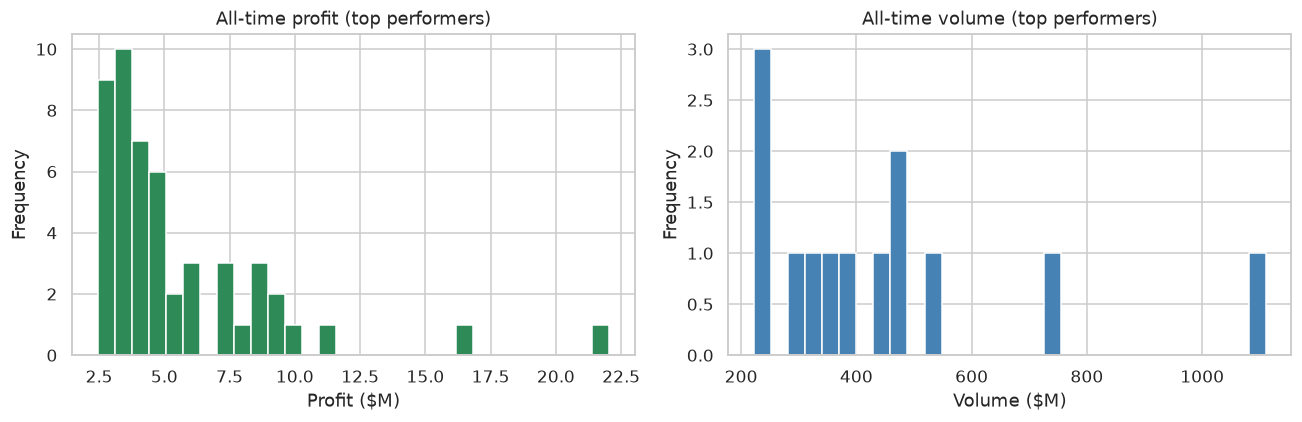

Median all-time profit: $4.28M


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
traders['profit_all'].dropna().div(1e6).plot(kind='hist', bins=30, ax=ax[0], color='seagreen')
ax[0].set(title='All-time profit (top performers)', xlabel='Profit ($M)')
traders['volume_all'].dropna().div(1e6).plot(kind='hist', bins=30, ax=ax[1], color='steelblue')
ax[1].set(title='All-time volume (top performers)', xlabel='Volume ($M)')
plt.tight_layout(); plt.show()
print('Median all-time profit: $%.2fM' % (traders['profit_all'].median()/1e6))

## 2 · Building the copyable-bets dataset

We restrict trades to **BUYs on markets that resolved with a known winner**, join
each trade's outcome token to the market's settlement, and compute the per-bet ROI
(here at a baseline **2% slippage**). This is the universe every strategy draws from.

In [4]:
SLIPPAGE = 0.02
bets = bt.build_bets(slippage=SLIPPAGE)
print(f"copyable bets: {len(bets):,} | traders represented: {bets['proxyWallet'].nunique()} "
      f"| resolved markets: {bets['conditionId'].nunique()}")
print(f"overall win rate: {bets['payout'].mean():.1%}")
print(f"NAIVE copy-all ROI (all data, in-sample): {bets['roi'].mean():+.2%}  <-- inflated, see split")
display(bets[['datetime','name','title','outcome','entry_price','payout','roi']].head())

copyable bets: 67,067 | traders represented: 88 | resolved markets: 1559
overall win rate: 66.4%
NAIVE copy-all ROI (all data, in-sample): +36.92%  <-- inflated, see split


,datetime,name,title,outcome,entry_price,payout,roi
0,2024-10-14 18:23:43+00:00,Michie,Will Donald Trump win the popular vote in the ...,Yes,0.3000,1.0000,2.2680
1,2024-10-14 18:23:43+00:00,Michie,Will Donald Trump win the popular vote in the ...,Yes,0.3000,1.0000,2.2680
2,2024-10-14 18:23:43+00:00,Michie,Will Donald Trump win the popular vote in the ...,Yes,0.3000,1.0000,2.2680
3,2024-10-14 18:23:43+00:00,Michie,Will Donald Trump win the popular vote in the ...,Yes,0.3000,1.0000,2.2680
4,2024-10-14 18:23:43+00:00,Michie,Will Donald Trump win the popular vote in the ...,Yes,0.3000,1.0000,2.2680


/tmp/ipykernel_11028/1061752267.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bets.groupby(bets['datetime'].dt.to_period('M').astype(str)).size().plot(kind='bar', ax=ax[1], color='darkorange')


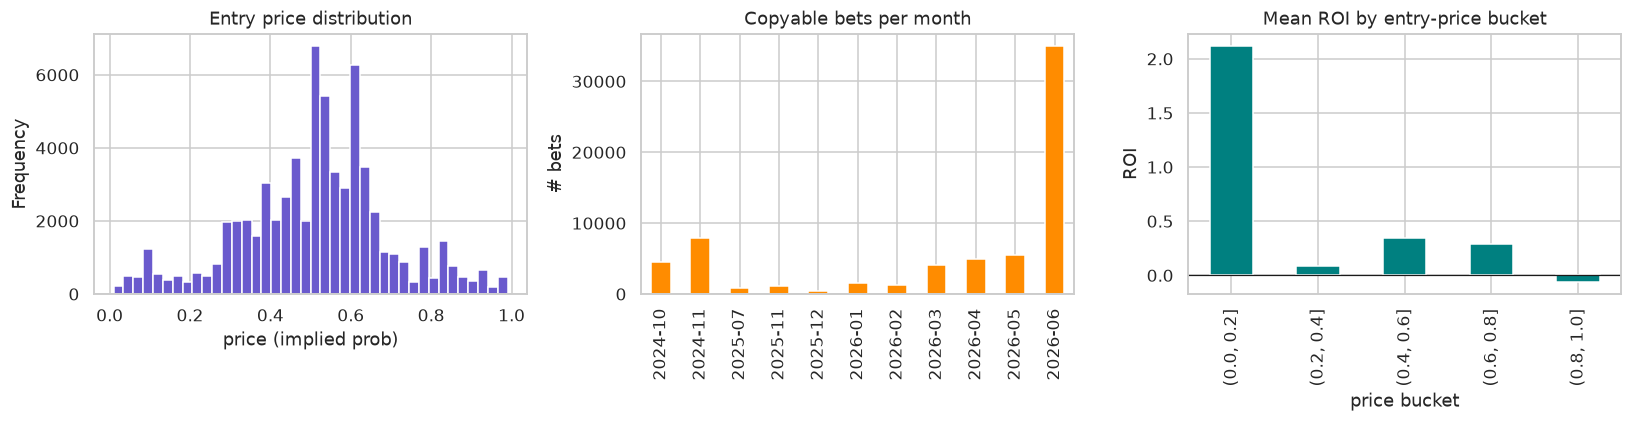

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
bets['entry_price'].plot(kind='hist', bins=40, ax=ax[0], color='slateblue')
ax[0].set(title='Entry price distribution', xlabel='price (implied prob)')
bets.groupby(bets['datetime'].dt.to_period('M').astype(str)).size().plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set(title='Copyable bets per month', xlabel='', ylabel='# bets')
# ROI by price bucket
bets['pb'] = pd.cut(bets['entry_price'], [0,.2,.4,.6,.8,1.0])
bets.groupby('pb', observed=True)['roi'].mean().plot(kind='bar', ax=ax[2], color='teal')
ax[2].set(title='Mean ROI by entry-price bucket', xlabel='price bucket', ylabel='ROI')
ax[2].axhline(0, color='k', lw=.8)
plt.tight_layout(); plt.show()

## 3 · Train / validation / test split (chronological)

We sort **all bets by execution time** and cut 60% / 20% / 20%. The split is
strictly time-ordered, so no future information leaks into earlier periods. Because
trading volume is heavily concentrated in recent weeks, the calendar windows for
val/test are short but each still contains thousands of bets — strong statistical
power for a genuine **out-of-sample** test of "does the copy edge persist forward?".

In [6]:
splits = bt.date_split(bets, train=0.6, val=0.2)
display(bt.split_ranges(splits))
train, val, test = splits['train'], splits['val'], splits['test']

,split,n_bets,start,end,n_markets,n_traders
0,train,40240,2024-10-14 18:23:43+00:00,2026-06-14 23:42:18+00:00,1099,56
1,val,13413,2026-06-14 23:42:19+00:00,2026-06-20 22:19:13+00:00,198,37
2,test,13414,2026-06-20 22:19:22+00:00,2026-06-23 16:39:49+00:00,283,37


## 4 · Copy-trading strategies

Seven ways to copy the cohort. Parameters (which wallets, thresholds, bands) are
**fit on train, tuned on validation, and only then scored on test**.

| # | Strategy | Idea |
|---|---|---|
| S1 | **Copy-all (equal)** | mirror every bet, \$1 each — the naive baseline |
| S2 | **Stake-weighted** | size each copy ∝ the trader's own USDC stake |
| S3 | **Consensus ≥ N** | only copy a market/outcome ≥ N cohort members bought |
| S4 | **Price band** | only copy bets whose entry price ∈ [lo, hi] |
| S5 | **Follow positive-edge wallets** | copy only wallets profitable *in train* |
| S6 | **Smart-money (edge-weighted)** | follow positive-edge wallets, weight by train edge |
| S7 | **Top-K wallets** | follow the K best wallets by train ROI |

All tunable parameters are selected by **maximising validation ROI**.

In [7]:
# --- Fit wallet-level edge on TRAIN only -------------------------------
edge = bt.wallet_edge(train, min_bets=20)
print(f"wallets with >=20 train bets: {len(edge)}")
display(edge.head(10)[['name','n','edge','win']])
good_wallets = edge[edge['edge'] > 0]['proxyWallet'].tolist()
wallet_w = dict(zip(edge['proxyWallet'], edge['edge'].clip(lower=0)))
print(f"positive-edge wallets carried forward: {len(good_wallets)}")

wallets with >=20 train bets: 53


,name,n,edge,win
16,Arbguy,313,4.4531,0.6933
44,wan123,322,4.1547,0.9472
33,jalenbrunson-official,131,1.7636,0.8702
12,mikatrade77,1000,1.4175,0.9910
25,BetTom42,1000,1.1632,1.0000
50,Michie,1000,0.8905,1.0000
9,muraibatu808,101,0.8854,1.0000
17,Theo4,1000,0.8735,0.9920
24,RepTrump,1000,0.8516,1.0000
38,alexmulti,1000,0.8228,1.0000


positive-edge wallets carried forward: 39


In [8]:
# --- Tune scalar hyper-parameters on VALIDATION ------------------------
def roi_of(fn_bets, fn_w):  # tiny helper
    return bt.evaluate(fn_bets, fn_w)['roi']

# Consensus N
cons = {N: roi_of(*bt.s_consensus(val, N)) for N in (2,3,5,8)}
best_N = max(cons, key=cons.get)
# Price band
bands = {(.5,.95):None,(.05,.5):None,(.3,.7):None,(.6,.9):None,(.05,.95):None}
band_roi = {b: roi_of(*bt.s_price_band(val,*b)) for b in bands}
best_band = max(band_roi, key=band_roi.get)
# Top-K
topk_by_edge = edge['proxyWallet'].tolist()
ks = {}
for K in (5,10,20,30):
    sub,w = bt.s_follow_topk(val, topk_by_edge[:K]); ks[K]=bt.evaluate(sub,w)['roi']
best_K = max(ks, key=ks.get)
print('Consensus ROI by N (val):', {k:round(v,4) for k,v in cons.items()}, '-> N*=',best_N)
print('Price-band ROI (val):', {k:round(v,4) for k,v in band_roi.items()}, '-> band*=',best_band)
print('Top-K ROI by K (val):', {k:round(v,4) for k,v in ks.items()}, '-> K*=',best_K)

Consensus ROI by N (val): {2: np.float64(0.4514), 3: np.float64(0.2174), 5: np.float64(0.6114), 8: nan} -> N*= 5
Price-band ROI (val): {(0.5, 0.95): np.float64(0.4535), (0.05, 0.5): np.float64(0.9318), (0.3, 0.7): np.float64(0.3161), (0.6, 0.9): np.float64(0.2011), (0.05, 0.95): np.float64(0.6995)} -> band*= (0.05, 0.5)
Top-K ROI by K (val): {5: np.float64(0.1144), 10: np.float64(0.1711), 20: np.float64(0.1249), 30: np.float64(0.0218)} -> K*= 10


## 5 · Evaluation across train / val / **test**

For each strategy we report ROI (return on deployed capital), win rate, number of
bets, and total P&L assuming \$1 of capital per unit weight. Watch the gap between
**train** (in-sample, survivorship-inflated) and **test** (held-out) — that gap is
the whole point.

In [9]:
def run(strategy_fn, frame):
    sub, w = strategy_fn(frame)
    return bt.evaluate(sub, w)

strategies = {
  'S1 copy-all':       lambda f: bt.s_copy_all(f),
  'S2 stake-weighted': lambda f: bt.s_stake_weighted(f),
  'S3 consensus>=%d'%best_N: lambda f: bt.s_consensus(f, best_N),
  'S4 price-band %s'%str(best_band): lambda f: bt.s_price_band(f, *best_band),
  'S5 follow +edge':   lambda f: bt.s_follow_topk(f, good_wallets),
  'S6 smart-money':    lambda f: bt.s_smart_money(f, good_wallets, wallet_w),
  'S7 top-%d wallets'%best_K: lambda f: bt.s_follow_topk(f, topk_by_edge[:best_K]),
}

rows=[]
for name, fn in strategies.items():
    for split_name, frame in [('train',train),('val',val),('test',test)]:
        r = run(fn, frame); r['strategy']=name; r['split']=split_name; rows.append(r)
results = pd.DataFrame(rows)
pivot = results.pivot(index='strategy', columns='split', values='roi')[['train','val','test']]
print('=== ROI by strategy and split ==='); display(pivot.style.format('{:+.2%}'))
print('\n=== TEST-period detail (held-out) ===')
display(results[results.split=='test'].set_index('strategy')[['n_bets','win_rate','roi','total_pnl','avg_price']])

=== ROI by strategy and split ===


split,train,val,test
strategy,,,
S1 copy-all,+38.74%,+68.48%,-0.12%
S2 stake-weighted,+34.08%,+64.64%,+31.27%
S3 consensus>=5,+91.80%,+61.14%,+64.38%
"S4 price-band (0.05, 0.5)",+41.88%,+93.18%,-0.81%
S5 follow +edge,+64.43%,+0.07%,+2.34%
S6 smart-money,+123.32%,+7.96%,-6.31%
S7 top-10 wallets,+132.10%,+17.11%,-96.34%



=== TEST-period detail (held-out) ===


,n_bets,win_rate,roi,total_pnl,avg_price
strategy,,,,,
S1 copy-all,13414,0.5118,-0.0012,-15.5605,0.5117
S2 stake-weighted,13414,0.5118,0.3127,"7,644,721.9093",0.5117
S3 consensus>=5,730,0.9589,0.6438,469.9736,0.6169
"S4 price-band (0.05, 0.5)",6910,0.3667,-0.0081,-56.0586,0.3648
S5 follow +edge,603,0.5871,0.0234,14.1013,0.4960
S6 smart-money,603,0.5871,-0.0631,-20.4688,0.4960
S7 top-10 wallets,47,0.0213,-0.9634,-45.2800,0.5521


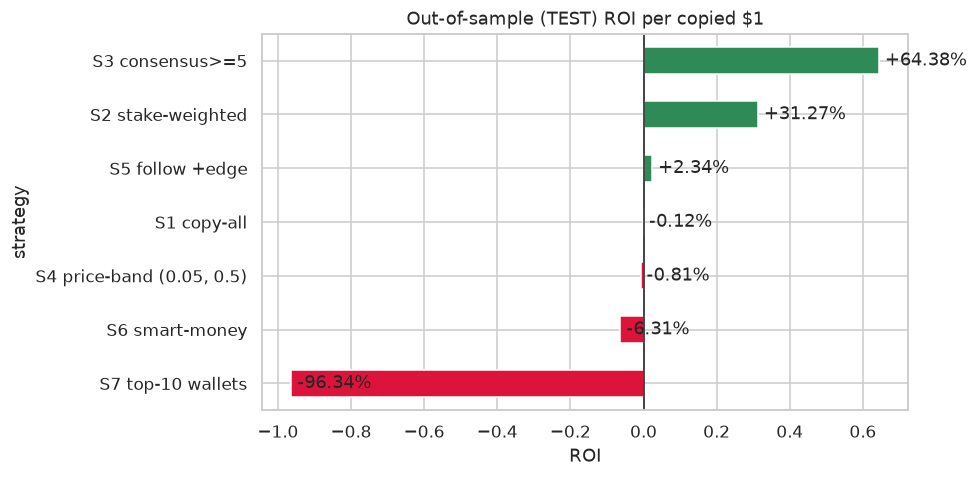

In [10]:
# Bar chart: test ROI by strategy
tt = results[results.split=='test'].set_index('strategy')['roi'].sort_values()
fig, ax = plt.subplots(figsize=(9,4.5))
colors=['crimson' if v<0 else 'seagreen' for v in tt.values]
tt.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0,color='k',lw=1); ax.set(title='Out-of-sample (TEST) ROI per copied $1', xlabel='ROI')
for i,v in enumerate(tt.values): ax.text(v, i, f' {v:+.2%}', va='center')
plt.tight_layout(); plt.show()

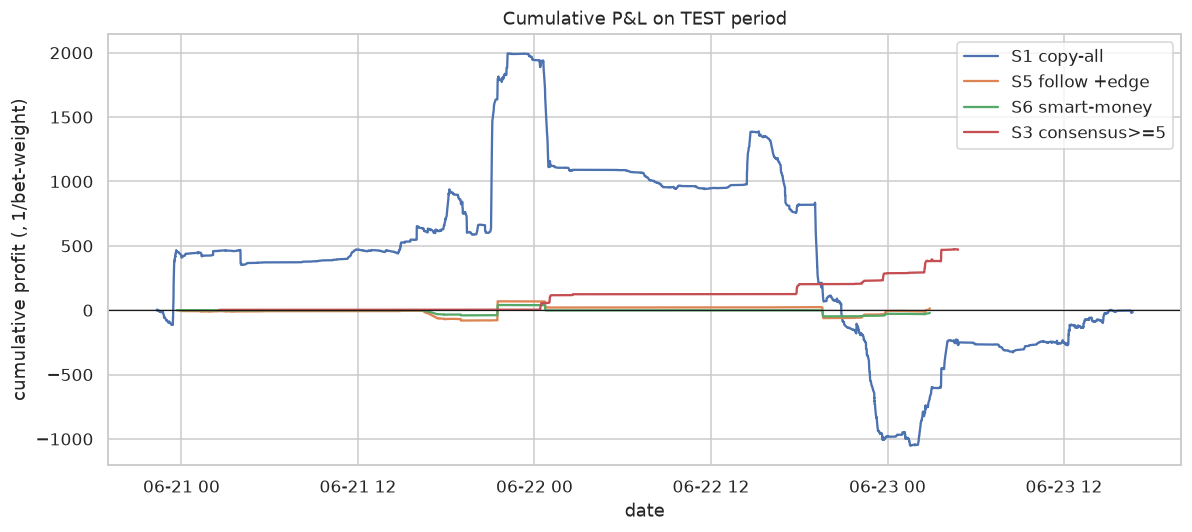

In [11]:
# Equity curves on the TEST period for the most interesting strategies
fig, ax = plt.subplots(figsize=(11,5))
for name in ['S1 copy-all','S5 follow +edge','S6 smart-money', 'S3 consensus>=%d'%best_N]:
    sub, w = strategies[name](test)
    if len(sub)==0: continue
    sub2 = sub.sort_values('timestamp')
    ww = np.asarray(w,float)[np.argsort(sub['timestamp'].values)]
    ax.plot(pd.to_datetime(sub2['datetime']), np.cumsum(ww*sub2['roi'].values), label=name)
ax.axhline(0,color='k',lw=.8); ax.legend(); ax.set(title='Cumulative P&L on TEST period',
       ylabel='cumulative profit ($, $1/bet-weight)', xlabel='date')
plt.tight_layout(); plt.show()

## 6 · Sensitivity to slippage

Copiers never get the trader's exact fill. We re-price the **test** bets at
0% / 1% / 2% / 5% slippage and recompute ROI — this is the difference between a
paper edge and a tradeable one.

In [12]:
sens=[]
for s in (0.0, 0.01, 0.02, 0.05):
    bb = bt.build_bets(slippage=s)
    sp = bt.date_split(bb, 0.6, 0.2); te = sp['test']
    for name, fn in [('S1 copy-all', lambda f: bt.s_copy_all(f)),
                     ('S5 follow +edge', lambda f: bt.s_follow_topk(f, good_wallets)),
                     ('S6 smart-money', lambda f: bt.s_smart_money(f, good_wallets, wallet_w))]:
        r = run(fn, te); sens.append({'slippage':f'{s:.0%}','strategy':name,'test_roi':r['roi']})
sens = pd.DataFrame(sens).pivot(index='strategy', columns='slippage', values='test_roi')
display(sens.style.format('{:+.2%}'))

slippage,0%,1%,2%,5%
strategy,,,,
S1 copy-all,+1.87%,+0.87%,-0.12%,-2.95%
S5 follow +edge,+4.39%,+3.35%,+2.34%,-0.59%
S6 smart-money,-4.44%,-5.39%,-6.31%,-8.99%


## 7 · What we learned

Quantitative conclusions are auto-generated below from the run; see
`reports/EXECUTIVE_SUMMARY.md` for the written write-up.

In [13]:
ca = pivot.loc['S1 copy-all']
best_test = results[results.split=='test'].set_index('strategy')['roi'].idxmax()
best_roi  = results[results.split=='test'].set_index('strategy')['roi'].max()
print('AUTO-GENERATED FINDINGS')
print('-'*60)
print(f'1. Naive copy-all: train {ca.train:+.1%} -> test {ca.test:+.1%} '
      f'({"edge collapses out-of-sample" if ca.test < 0.02 else "edge persists"})')
print(f'2. Best out-of-sample strategy: {best_test} at {best_roi:+.2%} ROI/bet')
print(f'3. Cohort raw win rate: {bets["payout"].mean():.1%} (favorite-heavy book)')
print(f'4. Slippage 0%->5% moves smart-money test ROI by '
      f'{(sens.loc["S6 smart-money"]["0%"]-sens.loc["S6 smart-money"]["5%"]):.2%}')

AUTO-GENERATED FINDINGS
------------------------------------------------------------
1. Naive copy-all: train +38.7% -> test -0.1% (edge collapses out-of-sample)
2. Best out-of-sample strategy: S3 consensus>=5 at +64.38% ROI/bet
3. Cohort raw win rate: 66.4% (favorite-heavy book)
4. Slippage 0%->5% moves smart-money test ROI by 4.55%
